In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import keras
from huggingface_hub import hf_hub_download

print("Downloading and loading model... (this may take 1-2 minutes)")
model_path = hf_hub_download(repo_id="Arko007/diabetic-retinopathy-v1", filename="best_model.h5")
model = keras.saving.load_model(model_path)

print("✅ Model loaded successfully!")
print("Input shape:", model.input_shape)

best_model.h5: reconstructing file:   0%|          |  0.00B / 4.77GB            

best_model.h5: downloading bytes:           |  0.00B            

✅ Model loaded successfully!
Input shape: (None, 384, 384, 3)


In [ ]:
!pip install -q opencv-python-headless matplotlib

In [ ]:
print("Model loaded successfully!")
print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)
model.summary()

Model loaded successfully!
Input shape : (None, 384, 384, 3)
Output shape: (None, 5)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 192,  │     18,944 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 192,  │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 96,    │    295,168 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │      1,024 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 96,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 96,    │     33,024 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 96, 96,    │          0 │ add[0][0]         │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 96, 96,    │    590,080 │ activation[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 96, 96,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 96, 96,    │          0 │ batch_normalizat

 Total params: 397,876,999 (1.48 GB)

 Trainable params: 397,807,621 (1.48 GB)

 Non-trainable params: 69,376 (271.00 KB)

 Optimizer params: 2 (8.00 B)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

GRADE_NAMES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

def preprocess_image(image_path, target_size=(384, 384)):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    return img

def predict_dr(image_path, show_image=True):
    img = preprocess_image(image_path)
    batch = np.expand_dims(img, axis=0)

    preds = model.predict(batch, verbose=0)[0]
    predicted_class = int(np.argmax(preds))
    confidence = float(preds[predicted_class])

    print("\n" + "="*55)
    print(f"Predicted Grade : {predicted_class}  →  {GRADE_NAMES[predicted_class]}")
    print(f"Confidence      : {confidence*100:.2f}%")
    print("-"*55)
    print("Class probabilities:")
    for i, p in enumerate(preds):
        bar = "█" * int(p * 30)
        print(f"  {i} ({GRADE_NAMES[i]:18s}): {p*100:6.2f}%  {bar}")
    print("="*55)

    if show_image:
        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.title(f"{GRADE_NAMES[predicted_class]} ({confidence*100:.1f}%)")
        plt.axis("off")
        plt.show()

    return {
        "grade": predicted_class,
        "label": GRADE_NAMES[predicted_class],
        "confidence": confidence,
        "probabilities": preds.tolist()
    }

print("✅ Prediction functions ready!")

✅ Prediction functions ready!


In [ ]:
# loading kagge tokens
!pip install -q kaggle

import os
os.environ['KAGGLE_API_TOKEN'] = "ADD-Your-KAggLE-TOKEN"  #our api token


print("✅ Kaggle token set!")

✅ Kaggle token set!


In [ ]:
print("Downloading IDRiD dataset... (this may take a few minutes)")
!kaggle datasets download -d mohamedabdalkader/indian-diabetic-retinopathy-image-dataset-idrid

print("Unzipping...")
!unzip -q indian-diabetic-retinopathy-image-dataset-idrid.zip -d IDRiD

print("✅ Dataset ready!")
!ls IDRiD

Dataset URL: https://www.kaggle.com/datasets/mohamedabdalkader/indian-diabetic-retinopathy-image-dataset-idrid
License(s): CC-BY-SA-4.0
100% 916M/916M [00:12<00:00, 78.9MB/s]

Unzipping...
✅ Dataset ready!
IDRiD


Total images found: 1548

Processing: IDRiD/IDRiD/Test/images/IDRiD_0223.jpg

Predicted Grade : 2  →  Moderate
Confidence      : 99.96%
-------------------------------------------------------
Class probabilities:
  0 (No DR             ):   0.04%  
  1 (Mild              ):   0.00%  
  2 (Moderate          ):  99.96%  █████████████████████████████
  3 (Severe            ):   0.00%  
  4 (Proliferative DR  ):   0.00%  


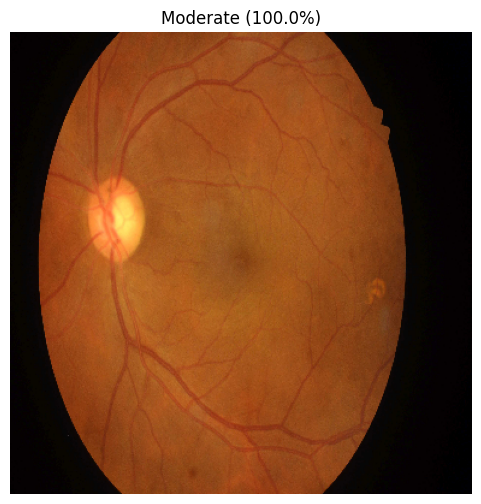


Processing: IDRiD/IDRiD/Test/images/IDRiD_0110.jpg

Predicted Grade : 4  →  Proliferative DR
Confidence      : 99.66%
-------------------------------------------------------
Class probabilities:
  0 (No DR             ):   0.00%  
  1 (Mild              ):   0.00%  
  2 (Moderate          ):   0.00%  
  3 (Severe            ):   0.34%  
  4 (Proliferative DR  ):  99.66%  █████████████████████████████


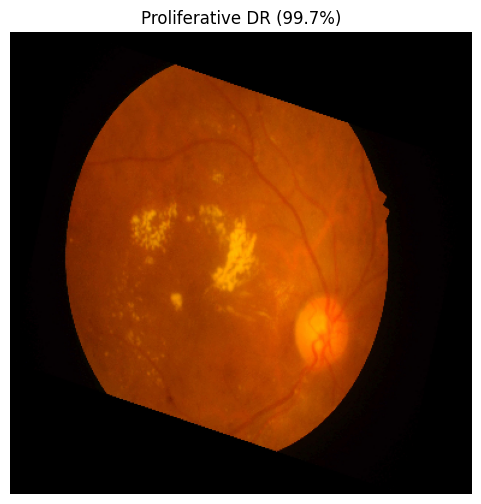


Processing: IDRiD/IDRiD/Test/images/IDRiD_0291.jpg

Predicted Grade : 2  →  Moderate
Confidence      : 100.00%
-------------------------------------------------------
Class probabilities:
  0 (No DR             ):   0.00%  
  1 (Mild              ):   0.00%  
  2 (Moderate          ): 100.00%  █████████████████████████████
  3 (Severe            ):   0.00%  
  4 (Proliferative DR  ):   0.00%  


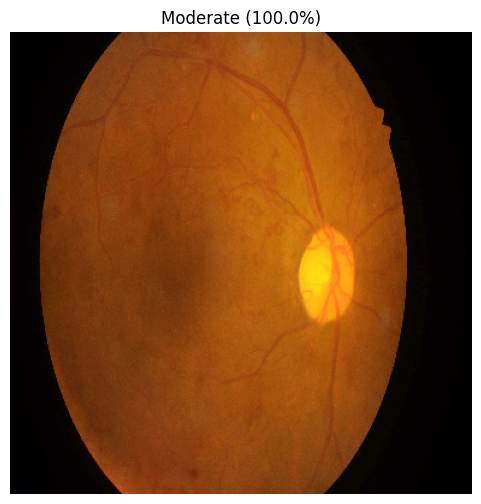


Processing: IDRiD/IDRiD/Test/images/IDRiD_0242.jpg

Predicted Grade : 2  →  Moderate
Confidence      : 99.84%
-------------------------------------------------------
Class probabilities:
  0 (No DR             ):   0.03%  
  1 (Mild              ):   0.00%  
  2 (Moderate          ):  99.84%  █████████████████████████████
  3 (Severe            ):   0.04%  
  4 (Proliferative DR  ):   0.08%  


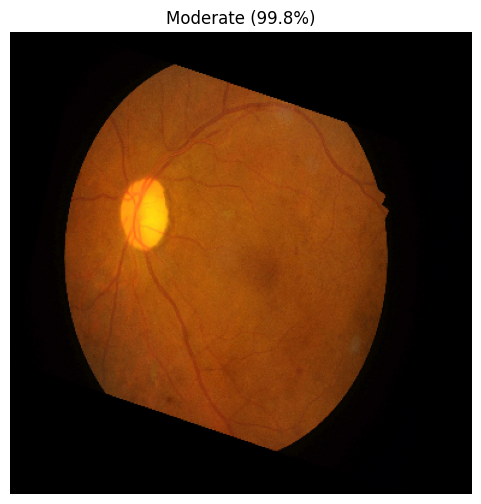


Processing: IDRiD/IDRiD/Test/images/IDRiD_0175.jpg

Predicted Grade : 3  →  Severe
Confidence      : 100.00%
-------------------------------------------------------
Class probabilities:
  0 (No DR             ):   0.00%  
  1 (Mild              ):   0.00%  
  2 (Moderate          ):   0.00%  
  3 (Severe            ): 100.00%  █████████████████████████████
  4 (Proliferative DR  ):   0.00%  


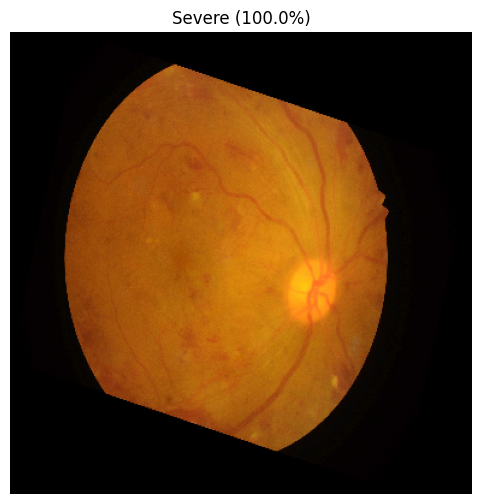

In [ ]:
import glob

image_paths = glob.glob("IDRiD/**/*.jpg", recursive=True) + \
              glob.glob("IDRiD/**/*.png", recursive=True) + \
              glob.glob("IDRiD/**/*.jpeg", recursive=True)

print(f"Total images found: {len(image_paths)}")

# Test first 5 images
for img_path in image_paths[:5]:
    print(f"\nProcessing: {img_path}")
    result = predict_dr(img_path)